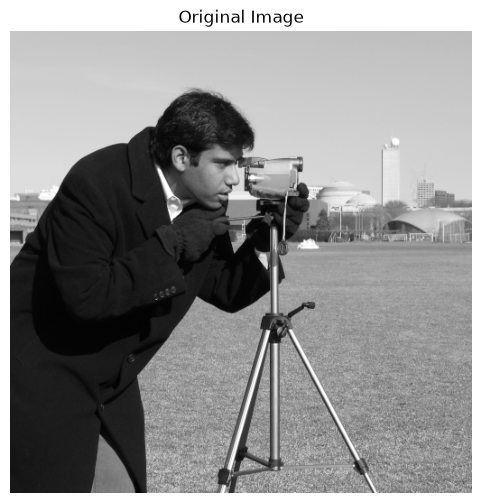

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

# Load a standard grayscale image
image = data.camera()

# Display the original image
plt.figure(figsize=(6, 6))
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

In [3]:
F=np.fft.fft2(image)
print("data type:",F.dtype)
print("shape;",F.shape)

data type: complex128
shape; (512, 512)


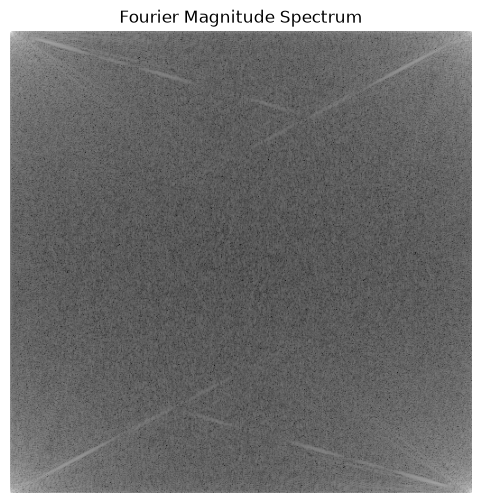

In [13]:
magnitude=np.abs(F)
plt.figure(figsize=(6, 6))
plt.imshow(np.log(1 + magnitude), cmap='gray')
plt.title("Fourier Magnitude Spectrum")
plt.axis('off')
plt.show()


In [14]:
F_shift = np.fft.fftshift(F)

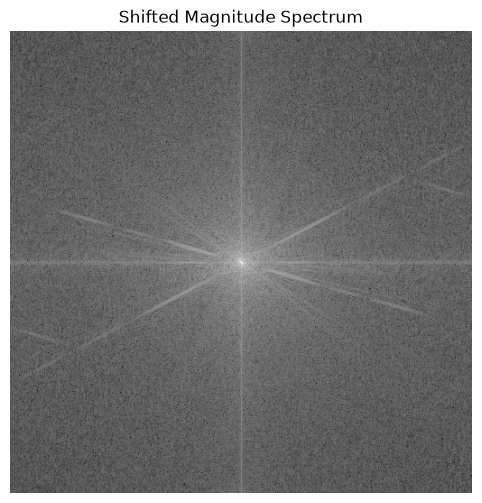

In [15]:
magnitude_shift = np.abs(F_shift)

plt.figure(figsize=(6, 6))
plt.imshow(np.log(1 + magnitude_shift), cmap='gray')
plt.title("Shifted Magnitude Spectrum")
plt.axis('off')
plt.show()

In [16]:
rows, cols = image.shape

crow = rows // 2
ccol = cols // 2

print(crow, ccol)

256 256


In [17]:
Y, X = np.ogrid[:rows, :cols]

distance = np.sqrt((X - ccol)**2 + (Y - crow)**2)

In [19]:
D0 = 50

In [20]:
high_pass_mask = np.where(distance <= D0, 0, 1)

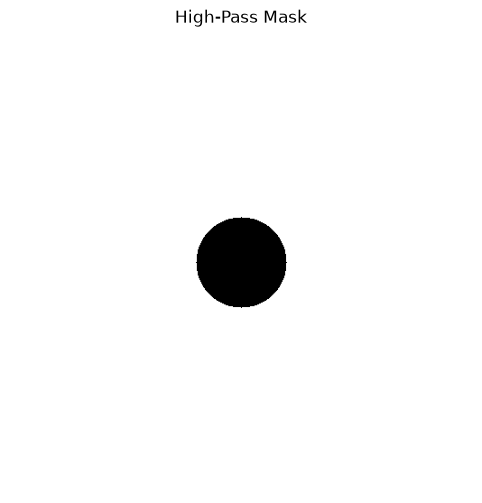

In [21]:
plt.figure(figsize=(6, 6))
plt.imshow(high_pass_mask, cmap='gray')
plt.title("High-Pass Mask")
plt.axis('off')
plt.show()

In [22]:
F_high = F_shift * high_pass_mask

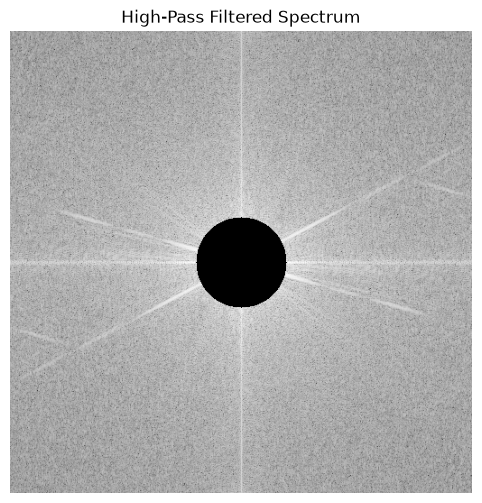

In [23]:
plt.figure(figsize=(6, 6))
plt.imshow(np.log(1 + np.abs(F_high)), cmap='gray')
plt.title("High-Pass Filtered Spectrum")
plt.axis('off')
plt.show()

In [24]:
F_high_unshift = np.fft.ifftshift(F_high)

In [25]:
high_freq = np.fft.ifft2(F_high_unshift)

In [31]:
high_freq = np.real(high_freq)

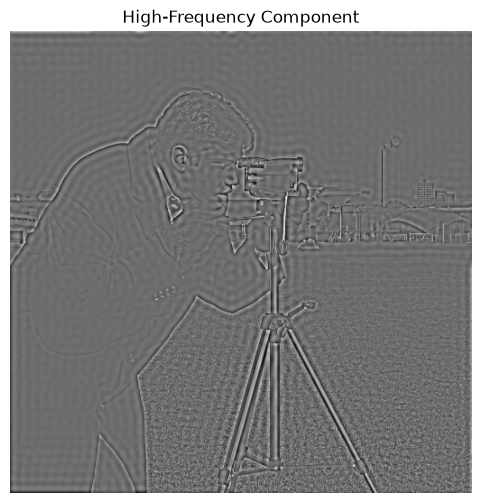

In [33]:
plt.figure(figsize=(6, 6))
plt.imshow(high_freq, cmap='gray')
plt.title("High-Frequency Component")
plt.axis('off')
plt.show()

In [34]:
image_float = image.astype(float)

In [35]:
sharpened = image_float + high_freq

In [ ]:
sharpened = np.clip(sharpened, 0, 255)

In [ ]:
sharpened = sharpened.astype(np.uint8)

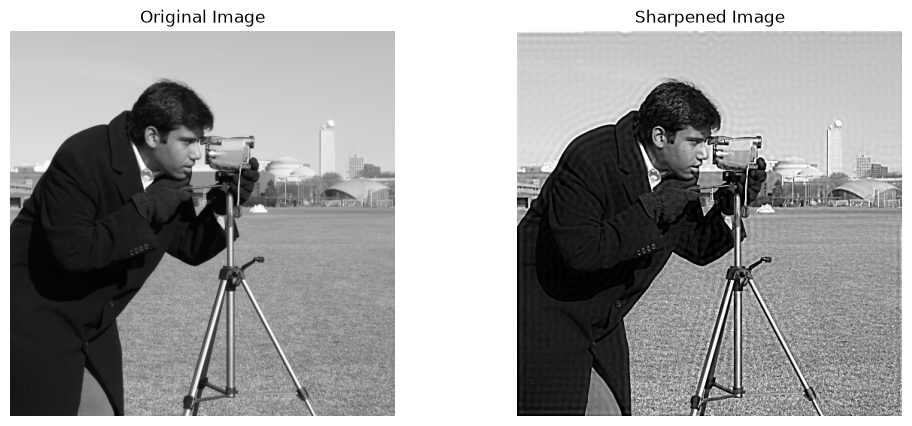

In [39]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(sharpened, cmap='gray')
plt.title("Sharpened Image")
plt.axis('off')

plt.show()

In [40]:
A = 2

In [41]:
high_boost = (A - 1) * image_float + sharpened

In [42]:
high_boost = np.clip(high_boost, 0, 255)

In [43]:
high_boost = high_boost.astype(np.uint8)

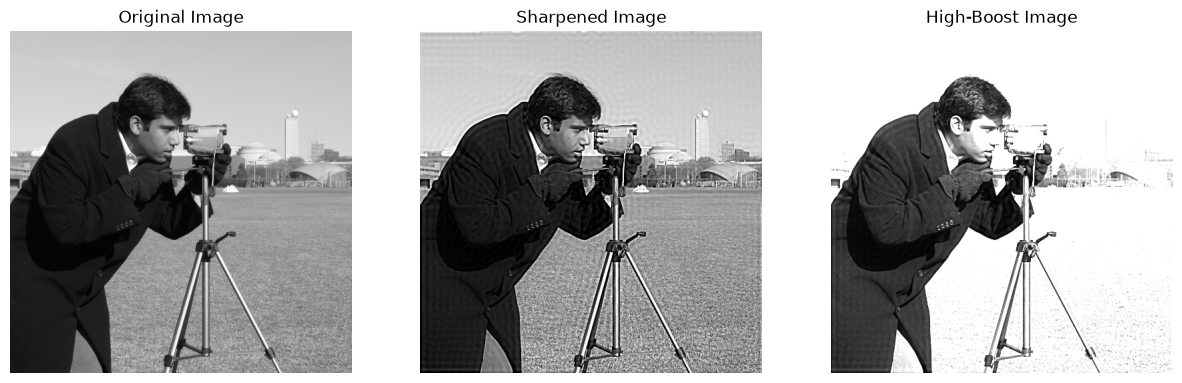

In [44]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sharpened, cmap='gray')
plt.title("Sharpened Image")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(high_boost, cmap='gray')
plt.title("High-Boost Image")
plt.axis('off')

plt.show()

adaptive local enhancement using gamma correction


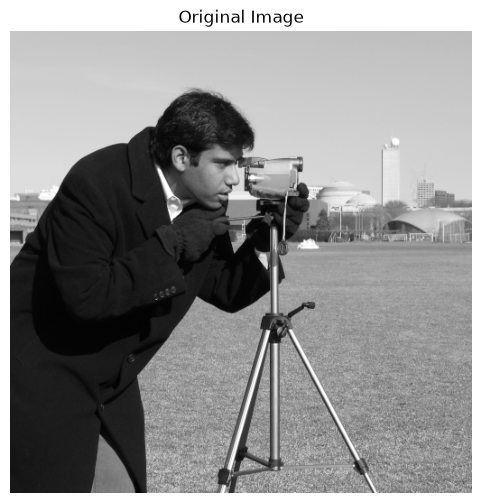

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

image = data.camera()

plt.figure(figsize=(6, 6))
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

In [55]:
rows, cols = image.shape
print(rows,cols)

512 512


In [56]:
mid_row = rows // 2
mid_col = cols // 2
print(mid_row,mid_col)

256 256


In [57]:
region1 = image[:mid_row, :mid_col]
print(region1)

[[200 200 200 ... 194 194 193]
 [200 199 199 ... 195 194 194]
 [199 199 199 ... 193 194 194]
 ...
 [156 155 156 ...   5   6   4]
 [158 157 157 ...   5   5   5]
 [159 158 130 ...   5   5   5]]


In [50]:
region2 = image[:mid_row, mid_col:]

In [51]:
region3 = image[mid_row:, :mid_col]

In [52]:
region4 = image[mid_row:, mid_col:]

In [53]:
mean1 = np.mean(region1)

In [54]:
mean1 = np.mean(region1)
mean2 = np.mean(region2)
mean3 = np.mean(region3)
mean4 = np.mean(region4)

print(mean1)
print(mean2)
print(mean3)
print(mean4)

125.68867492675781
178.90785217285156
65.68067932128906
145.9656982421875


In [58]:
threshold = 128

if mean1 < threshold:
    print("Region 1: Dark")
else:
    print("Region 1: Bright")

Region 1: Dark


In [59]:
def choose_gamma(mean_value):
    if mean_value < threshold:
        return 0.5
    else:
        return 2.0

In [60]:
gamma1 = choose_gamma(mean1)
gamma2 = choose_gamma(mean2)
gamma3 = choose_gamma(mean3)
gamma4 = choose_gamma(mean4)

In [61]:
print("Region 1:", mean1, "→ γ =", gamma1)
print("Region 2:", mean2, "→ γ =", gamma2)
print("Region 3:", mean3, "→ γ =", gamma3)
print("Region 4:", mean4, "→ γ =", gamma4)

Region 1: 125.68867492675781 → γ = 0.5
Region 2: 178.90785217285156 → γ = 2.0
Region 3: 65.68067932128906 → γ = 0.5
Region 4: 145.9656982421875 → γ = 2.0


In [65]:
region1_corrected = (region1 / 255.0) ** gamma1 * 255
region2_corrected = (region2 / 255.0) ** gamma2 * 255
region3_corrected = (region3 / 255.0) ** gamma3 * 255
region4_corrected = (region4 / 255.0) ** gamma4 * 255

In [66]:
enhanced = np.zeros_like(image, dtype=float)

In [67]:
enhanced[:mid_row, :mid_col] = region1_corrected

In [68]:
enhanced[:mid_row, mid_col:] = region2_corrected

In [69]:
enhanced[mid_row:, :mid_col] = region3_corrected

In [70]:
enhanced[mid_row:, mid_col:] = region4_corrected

In [71]:
enhanced = np.clip(enhanced, 0, 255)

In [72]:
enhanced = enhanced.astype(np.uint8)

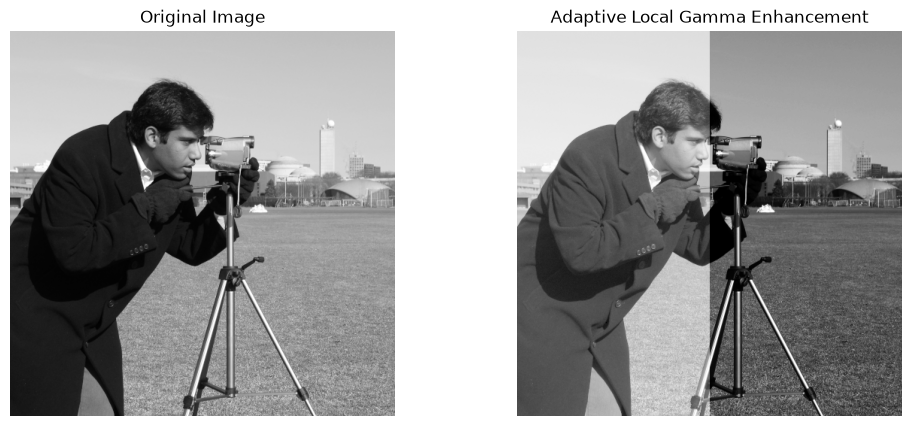

In [73]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(enhanced, cmap='gray')
plt.title("Adaptive Local Gamma Enhancement")
plt.axis('off')

plt.show()